In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from ccsnlab.sn_types import sn_types, sn_subtypes
from ccsnlab.plotting.ratios import plot_I_over_II_one_curve, plot_loss_data
from ccsnlab.plotting.subtypes import plot_I_or_II_subtypes, add_shivvers_point

from matplotlib import rcParams
rcParams.update({'xtick.major.pad': '5.0'})
rcParams.update({'xtick.major.size': '5.5'})
rcParams.update({'xtick.major.width': '1.0'})
rcParams.update({'xtick.minor.pad': '5.0'})
rcParams.update({'xtick.minor.size': '2.5'})
rcParams.update({'xtick.minor.width': '1.0'})
rcParams.update({'ytick.major.pad': '5.0'})
rcParams.update({'ytick.major.size': '5.5'})
rcParams.update({'ytick.major.width': '1.0'})
rcParams.update({'ytick.minor.pad': '5.0'})
rcParams.update({'ytick.minor.size': '2.5'})
rcParams.update({'ytick.minor.width': '1.0'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'axes.labelpad': '10.0'})
rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"]=[12.0,8.0]

The sample dataframe is the Klencki α=0.7 model.

In [2]:
sample_data = pd.read_hdf('../processed_data/qcflag_5_merger_prescription_Klencki_0.7.h5', key='data')

By default, the dataframes classify Type II CCSNe as those with hydrogen ejecta mass ≥ 0.03 M⊙. By changing this option in `sn_types`, I will reclassify the population with a few variations for this threshold, and print out the ratio NI/ NII.

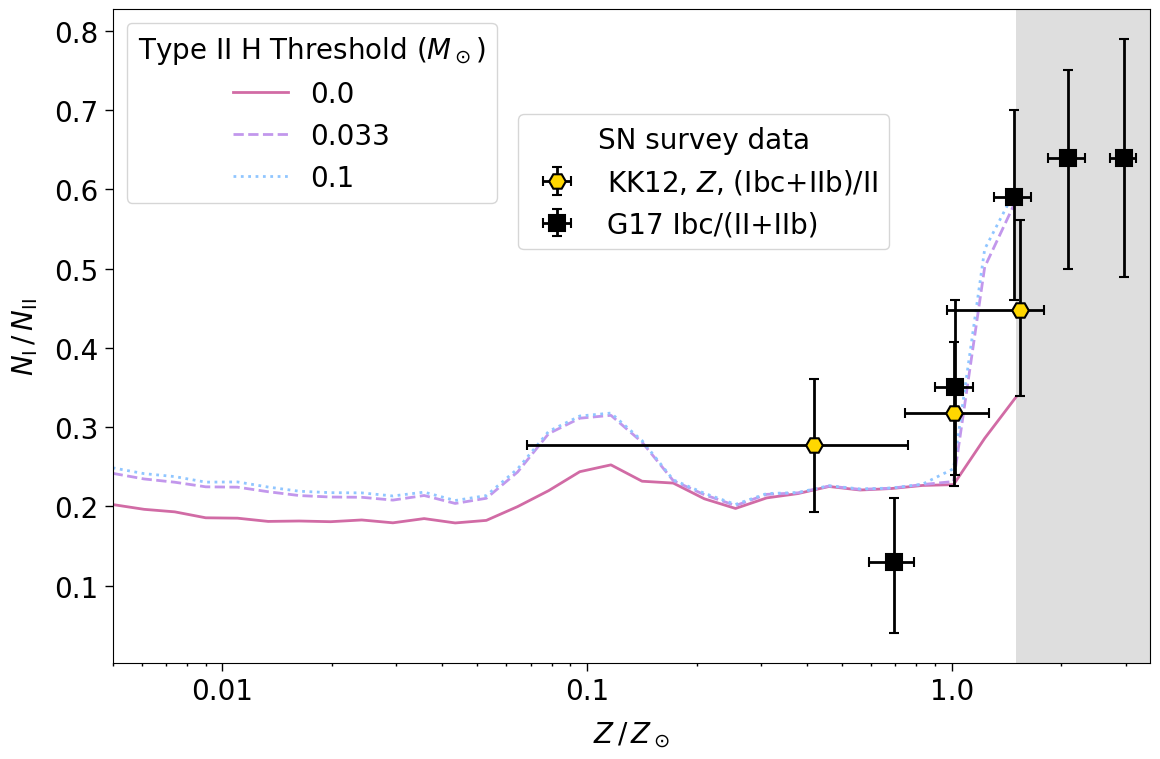

In [3]:
fig, ax = plt.subplots()
colors = ['#d16ba5', '#c297ec', '#90c6ff']
linestyles = ['-', '--', ':']
thresholds = [0.0, 0.033, 0.1]

#reclassify each model and plot
for thresh, color, linestyle in zip(thresholds, colors, linestyles):
    reclassed = sn_types(sample_data, II_h_thresh = thresh)
    plot_I_over_II_one_curve(reclassed, reclassed.met_cosmic.unique(), ax, f'{thresh}',
                             bh_cap=3.0, color=color, linestyle=linestyle, singles_only=False)

#legend for lines
legend = ax.legend(loc='upper left', title=r'Type II H Threshold ($M_\odot$)')
ax.add_artist(legend)

#add the data from LOSS and KK12                                      
handles = plot_loss_data(ax, label_loss=True, solar=9.0)
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.57, 0.86),
          labels=[r'KK12, $Z$, (Ibc+IIb)/II', 'G17 Ibc/(II+IIb)'], title='SN survey data')                                                
                    
#format the axis
ax.axvspan(1.5, 3.5, facecolor='lightgrey', alpha=0.75)
ax.set_xscale('log')
ax.set_xlim(5e-3, 3.5)
ax.set_xlabel(r'$Z \,/\, Z_\odot$')
ax.set_ylabel(r'$N_{\text{I}} \,/\, N_{\text{II}}$')
x_ticks = [0.01, 0.1, 1.0]
ax.set_xticks(x_ticks, labels=[str(xt) for xt in x_ticks])

fig.tight_layout()
plt.show()

By default, the dataframes are classified with the "*branch IIP first*" scheme for Type II CCSNe, and the standard hydrogen ejecta thresholds -- 0.91 M⊙ for IIb-IIL boundary, and 4.5 M⊙ for IIL-IIP boundary. Type I CCSNe are classified with the "*relative helium*" scheme, with the helium mass to total ejecta mass ratio of 0.43. The function `sn_subtypes` has the option to vary each of these quantities.

First I will edit each of the quantities relevant to the classification of Type II CCSNe, and plot a pie chart of the resulting subtypes.

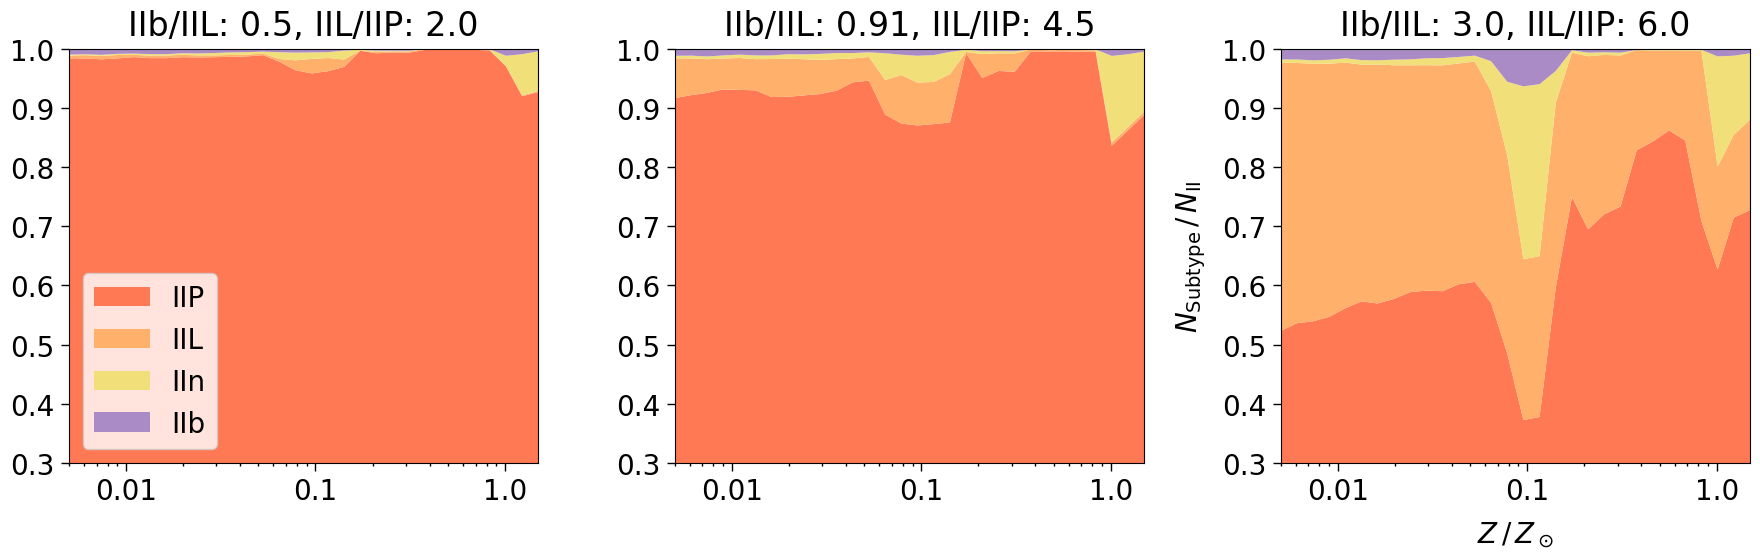

In [4]:
#default: IIb_IIL_h_thresh = 0.91, IIL_IIP_h_thresh = 4.5,

IIb_IIL_thresholds = [0.5, 0.91, 3.0]
IIL_IIP_thresholds = [2.0, 4.5, 6.0]
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for IIb_IIL_thresh, IIL_IIP_thresh, ax in zip(IIb_IIL_thresholds, IIL_IIP_thresholds, axes.flatten()):
    reclassed = sn_subtypes(sample_data,
                            IIb_IIL_h_thresh=IIb_IIL_thresh,
                            IIL_IIP_h_thresh=IIL_IIP_thresh,
                            IIP_scheme='branch IIP first')
    plot_I_or_II_subtypes(reclassed, 'II', ax)
    ax.set_title(f'IIb/IIL: {IIb_IIL_thresh}, IIL/IIP: {IIL_IIP_thresh}')


ax.set_xlabel(r'$Z \,/\, Z_\odot$')
ax.set_ylabel(r'$N_{\text{Subtype}} \,/\, N_{\text{II}}$')
axes.flatten()[0].legend(loc='lower left')
x_ticks = [0.01, 0.1, 1.0]
for ax in axes.flatten():
    ax.set_xscale('log')
    ax.set_xlim(5e-3, 1.5)
    ax.set_xticks(x_ticks, labels=[str(xt) for xt in x_ticks])
    ax.set_ylim(0.3, 1.0)
fig.tight_layout()
plt.show()

Now I will classify Type I CCSNe by the absolute amount of helium in their ejecta, and vary this threshold!

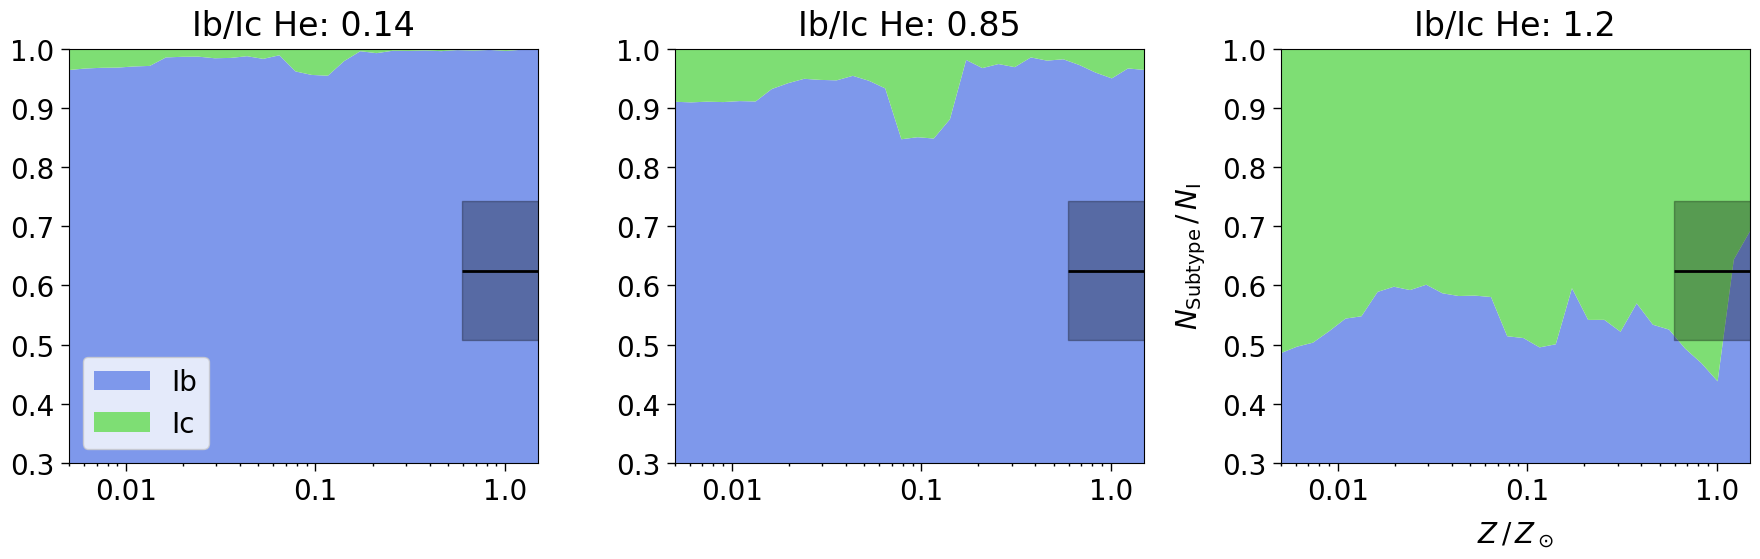

In [5]:
#default: Ib_Ic_he_thresh = 0.14

Ib_Ic_he_thresholds = [0.14, 0.85, 1.2]
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for Ib_Ic_he_thresh, ax in zip(Ib_Ic_he_thresholds, axes.flatten()):
    reclassed = sn_subtypes(sample_data,
                            Ic_scheme='absolute',
                            Ib_Ic_he_thresh=Ib_Ic_he_thresh)
    plot_I_or_II_subtypes(reclassed, 'I', ax)
    ax.set_title(f'Ib/Ic He: {Ib_Ic_he_thresh}')

    #add the Shivvers+2017 data
    add_shivvers_point(ax)

ax.set_xlabel(r'$Z \,/\, Z_\odot$')
ax.set_ylabel(r'$N_{\text{Subtype}} \,/\, N_{\text{I}}$')
x_ticks = [0.01, 0.1, 1.0]
for ax in axes.flatten():
    ax.set_xscale('log')
    ax.set_xlim(5e-3, 1.5)
    ax.set_xticks(x_ticks, labels=[str(xt) for xt in x_ticks])
    ax.set_ylim(0.3, 1.0)

axes.flatten()[0].legend(loc='lower left')
fig.tight_layout()
plt.show()